In [1]:
import pandas as pd
import sqlite3
from pandas.plotting import scatter_matrix

In [2]:
conn = sqlite3.connect('../data/checking-logs.sqlite')

In [3]:
query = """
SELECT 
    pv.uid,
    AVG((CAST(strftime('%s', c.timestamp) AS REAL) - d.deadlines) / 3600.0) as avg_diff,
    (SELECT COUNT(*) FROM pageviews p WHERE p.uid = pv.uid) as pageviews,
    (SELECT COUNT(*) FROM checker ch WHERE ch.uid = pv.uid AND ch.labname != 'project1' AND ch.timestamp IS NOT NULL) as commits
FROM (SELECT DISTINCT uid FROM pageviews WHERE uid NOT LIKE 'admin_%') pv
LEFT JOIN checker c ON pv.uid = c.uid
LEFT JOIN deadlines d ON c.labname = d.labs
WHERE c.labname != 'project1'
    AND c.timestamp IS NOT NULL
GROUP BY pv.uid
ORDER BY pv.uid
"""

df = pd.io.sql.read_sql(query, conn)

In [ ]:
df = df.drop(columns=['uid'])

In [7]:
df.shape

(11, 3)

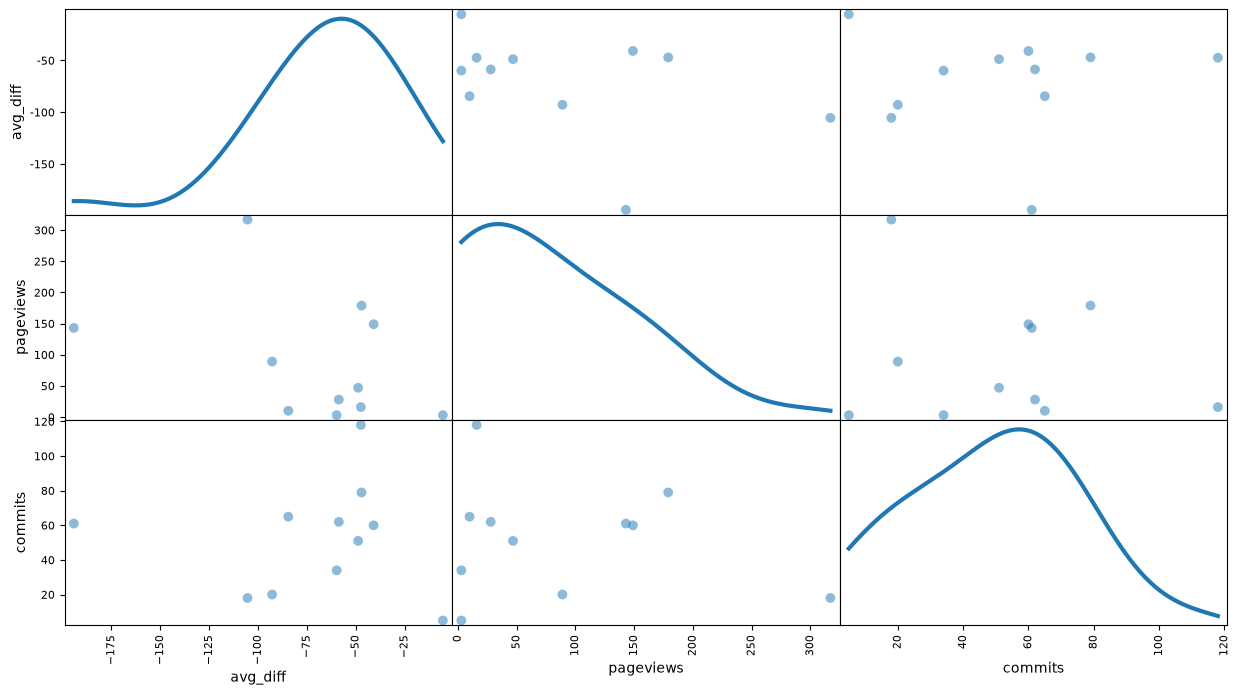

In [5]:
axes = scatter_matrix(df, figsize=(15, 8), diagonal='kde', s=200)
for ax in axes.diagonal():
    for line in ax.lines:
        line.set_linewidth(3)

In [6]:
conn.close()

Можно ли сказать, что если у пользователя мало просмотров ленты, то у него, вероятно, мало коммитов?

Ответ: no

Можно ли сказать, что если у пользователя мало просмотров ленты, то у него, вероятно, малая средняя разница между первым коммитом и дедлайном лабораторной?

Ответ: no

Можно ли сказать, что много пользователей с малым числом коммитов и немного — с большим числом коммитов?

Ответ: yes

Можно ли сказать, что много пользователей с малой средней разницей и немного — с большой средней разницей?

Ответ: no